# Notebook 04: Forecasting, Uncertainty Quantification & XAI

## 1. Overview
In this final stage, we perform inference using the "Champion" LSTM model. We transition from predicting annual variations ($\Delta K_t$) to projecting long-term mortality levels ($K_t$) and life expectancy.

## 2. Methodology
- **Recursive Forecasting**: Using predicted variations to reconstruct future mortality indices step-by-step up to 2050.
- **Monte Carlo Dropout**: Activating dropout layers during inference to generate stochastic trajectories and fan charts.
- **Back-Transformation**: Converting latent factors back into death rates ($m_x$) and survival probabilities ($q_x$).
- **Explainability (XAI)**: Analyzing feature importance to understand cluster-wide influences.

## 4.1: Environment Setup and Asset Loading

In [1]:
import os
import sys
import logging
import warnings

# 1. SILENCE SYSTEM WARNINGS (Before importing heavy libraries)
# Silence urllib3/LibreSSL warnings
warnings.filterwarnings("ignore", category=UserWarning, module="urllib3")
# Silence Keras optimizer/variable loading warnings
warnings.filterwarnings("ignore", message="Skipping variable loading for optimizer")

# Silence TensorFlow C++ info/warnings (Metal/NUMA info)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import joblib

# Silence TensorFlow Python-level warnings
tf.get_logger().setLevel(logging.ERROR)

# 2. Setup Style and Paths
sys.path.append('../src/')
from style_config import set_style
COUNTRIES_DICT = set_style()
FIGURES_DIR = "../reports/figures/"
MODELS_DIR = "../models/"

# 3. Load serialized assets from Notebook 03
model_path = os.path.join(MODELS_DIR, "mortality_lstm_champion.keras")
scaler_path = os.path.join(MODELS_DIR, "data_scaler.pkl")

if not os.path.exists(model_path) or not os.path.exists(scaler_path):
    raise FileNotFoundError("Assets not found. Please run Notebook 03 serialization cell first.")

# Loading the "Champion" model
# We set compile=False because we only need the model for inference (forecasting),
# which avoids the optimizer mismatch warnings entirely.
mortality_model = tf.keras.models.load_model(model_path, compile=False)
scaler = joblib.load(scaler_path)

# 4. Load processed factors to get the "starting point" (last known year: 2020)
DATA_PATH = "../data/processed/benchmarking_factors.npz"
with np.load(DATA_PATH, allow_pickle=True) as data:
    kt_global = data['kt_common']        
    kt_local_matrix = data['kt_specific_matrix'] 
    years = data['years']
    country_codes = data['countries']

# Reconstruct the full features (Levels)
full_features = np.column_stack([kt_global, kt_local_matrix])
last_year = years[-1]

print(f"--- Environment Ready ---")
print(f"Model loaded successfully: {mortality_model.name}")
print(f"Base Year for Forecast: {last_year}")
print(f"Target: Recursive forecasting up to 2050")

/Users/darindor2101/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


--- Environment Ready ---
Model loaded successfully: functional_1
Base Year for Forecast: 2020
Target: Recursive forecasting up to 2050


## 4.2: Stochastic Recursive Forecasting (Monte Carlo Dropout)

In [2]:
def forecast_with_uncertainty(model, initial_sequence, n_steps, n_simulations=500):
    """
    Performs recursive forecasting with Monte Carlo Dropout and progress monitoring.
    """
    n_features = initial_sequence.shape[-1]
    all_sims_diffs = np.zeros((n_simulations, n_steps, n_features))
    
    print(f"Starting {n_simulations} Monte Carlo simulations...")
    
    # 1. Prepare input tensor shape once to avoid repeated warnings
    # We ensure the tensor is explicitly cast to float32
    
    for sim in range(n_simulations):
        current_seq = initial_sequence.copy()
        
        for step in range(n_steps):
            # Convert to tensor and add batch dimension to satisfy Keras expectations
            input_tensor = tf.convert_to_tensor(current_seq[np.newaxis, ...], dtype=tf.float32)
            
            # training=True keeps Dropout active during inference
            pred_diff_scaled = model(input_tensor, training=True)
            
            # Extract and reshape
            pred_val = pred_diff_scaled.numpy().reshape(n_features)
            
            # Store the predicted difference
            all_sims_diffs[sim, step, :] = pred_val
            
            # Update the sequence for the next recursive step
            current_seq = np.roll(current_seq, -1, axis=0)
            current_seq[-1] = pred_val
            
        # Progress Print every 10%
        if (sim + 1) % (n_simulations // 10) == 0:
            print(f"Progress: {((sim + 1) / n_simulations) * 100:.0f}% complete...")
            
    return all_sims_diffs

# 1. Prepare starting sequence
diff_features = np.diff(full_features, axis=0)
diff_scaled = scaler.transform(diff_features)
initial_sequence = diff_scaled[-10:] 

# 2. Run the Forecast
N_YEARS_AHEAD = 30
simulated_diffs_scaled = forecast_with_uncertainty(
    mortality_model, 
    initial_sequence, 
    n_steps=N_YEARS_AHEAD, 
    n_simulations=1000 
)

print(f"\n--- Simulations Complete ---")
print(f"Shape: {simulated_diffs_scaled.shape} (Simulations, Years, Factors)")

Starting 1000 Monte Carlo simulations...
Progress: 10% complete...
Progress: 20% complete...
Progress: 30% complete...
Progress: 40% complete...
Progress: 50% complete...
Progress: 60% complete...
Progress: 70% complete...
Progress: 80% complete...
Progress: 90% complete...
Progress: 100% complete...

--- Simulations Complete ---
Shape: (1000, 30, 7) (Simulations, Years, Factors)


## 4.3: Reconstructing Levels from Differences (Stochastic Integration)

In [3]:
# 1. Define feature count and Reshape
# n_features is 7 (1 Global + 6 Specific)
n_features = simulated_diffs_scaled.shape[2] 

# Flatten to (1000*30, 7) to apply the inverse scaling
flat_diffs = simulated_diffs_scaled.reshape(-1, n_features)
flat_diffs_real = scaler.inverse_transform(flat_diffs)

# Reshape back to (Simulations, Years, Features)
sims_diffs_real = flat_diffs_real.reshape(1000, N_YEARS_AHEAD, n_features)

# 2. Cumulative Sum (Integration)
# Starting point: the last known levels in 2020 (from Notebook 02)
last_level_2020 = full_features[-1]

# Create storage for levels: (1000, 31, 7) -> includes 2020 as year 0
sims_levels = np.zeros((1000, N_YEARS_AHEAD + 1, n_features))
sims_levels[:, 0, :] = last_level_2020

# Progressively add the predicted differences to the previous level
for t in range(1, N_YEARS_AHEAD + 1):
    sims_levels[:, t, :] = sims_levels[:, t-1, :] + sims_diffs_real[:, t-1, :]

# 3. Calculate Percentiles for the Common Factor (Feature 0)
forecast_years = np.arange(last_year, last_year + N_YEARS_AHEAD + 1)
kt_common_sims = sims_levels[:, :, 0] # Extract only the Global Trend (Li-Lee Kt)

median_kt = np.percentile(kt_common_sims, 50, axis=0)
lower_95 = np.percentile(kt_common_sims, 2.5, axis=0)
upper_95 = np.percentile(kt_common_sims, 97.5, axis=0)
lower_80 = np.percentile(kt_common_sims, 10, axis=0)
upper_80 = np.percentile(kt_common_sims, 90, axis=0)

print(f"--- Levels Reconstructed ---")
print(f"Forecast Horizon: {last_year} -> {forecast_years[-1]}")
print(f"Median Kt in 2050: {median_kt[-1]:.2f}")
print(f"95% Confidence Interval in 2050: [{lower_95[-1]:.2f}, {upper_95[-1]:.2f}]")

--- Levels Reconstructed ---
Forecast Horizon: 2020 -> 2050
Median Kt in 2050: -123.63
95% Confidence Interval in 2050: [-125.26, -121.87]


## 4.4: Fan Chart Visualization of Global Mortality Trend ($K_t$)

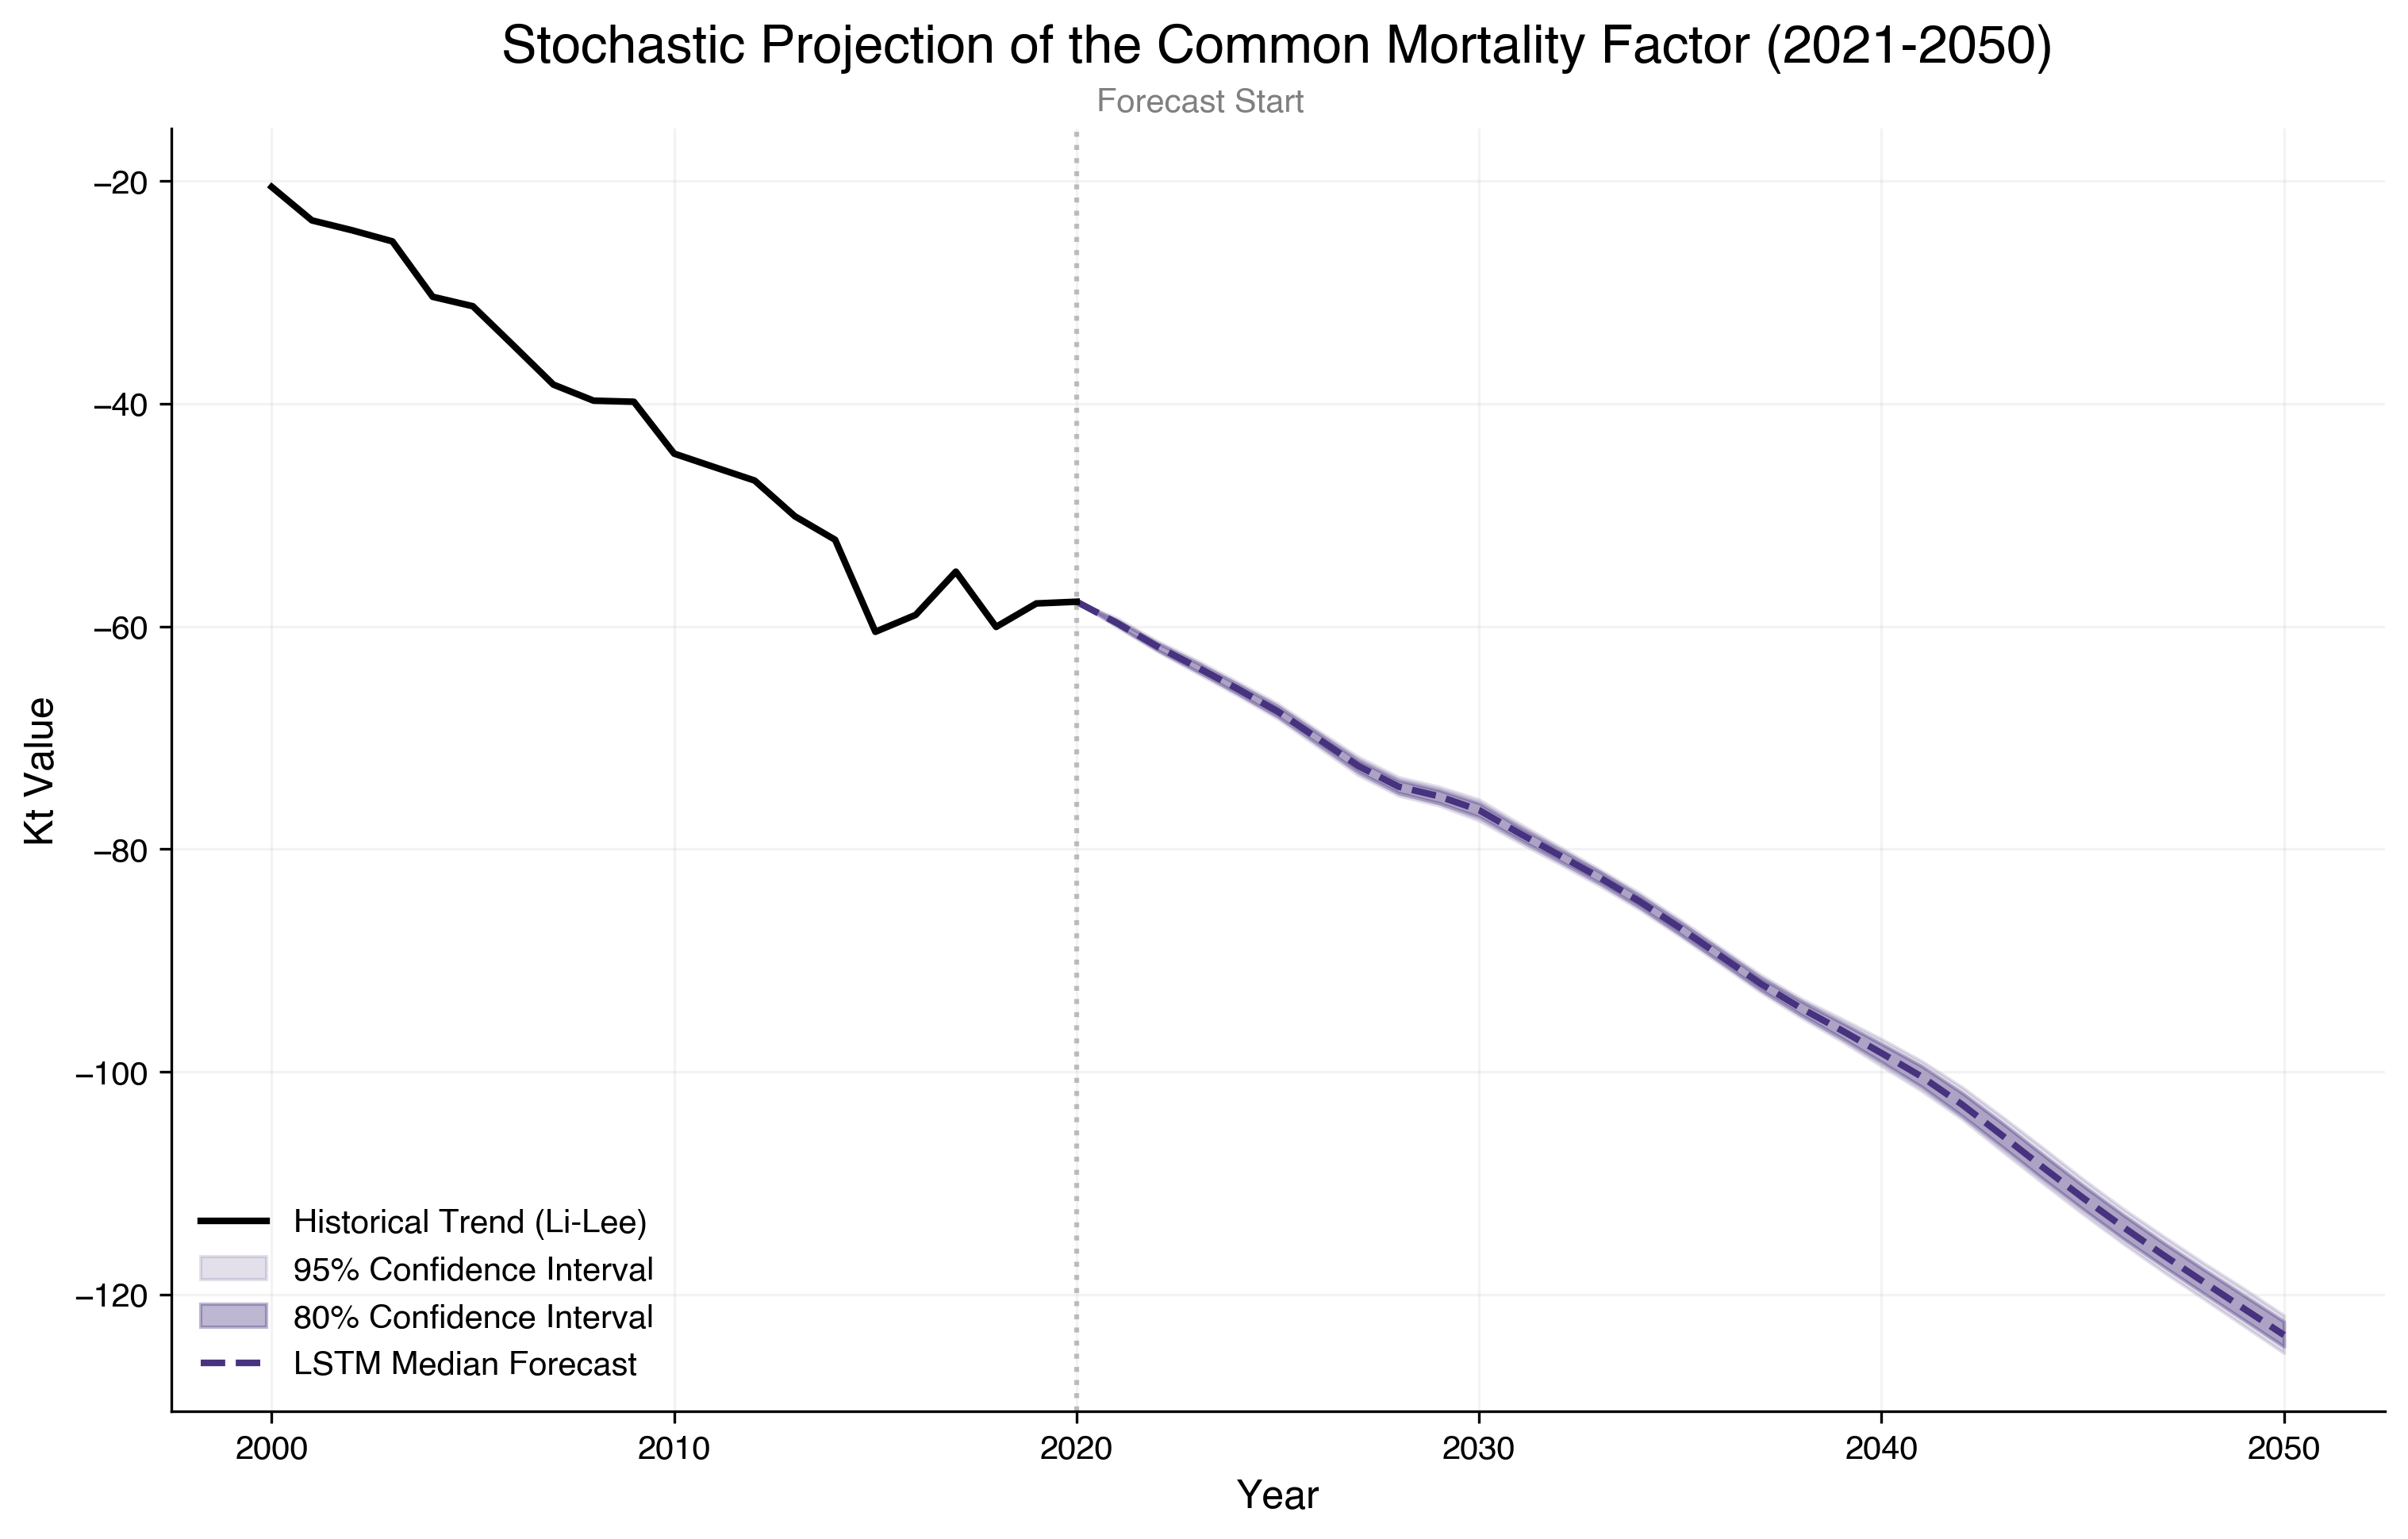

--- Fan Chart (Fig 09) successfully generated and saved ---
Path: ../reports/figures/fig09_kt_stochastic_forecast.png


In [4]:
import seaborn as sns

# 1. Retrieve the color palette and constants
# COUNTRIES_DICT was returned by set_style() in Cell 4.1
current_palette = sns.color_palette("viridis", len(COUNTRIES_DICT))
main_color = current_palette[0] # Using the first color for the common trend

# 2. Setup Plot (Size and DPI are handled by rcParams in style_config)
fig, ax = plt.subplots()

# 3. Plot Historical Data (Focus on 2000-2020 for recent context)
mask_hist = (years >= 2000)
ax.plot(years[mask_hist], kt_global[mask_hist], 
        color='black', 
        label='Historical Trend (Li-Lee)', 
        linewidth=2, 
        zorder=5)

# 4. Plot Stochastic Forecast (Fan Chart)
# 95% Confidence Interval (Lightest shade)
ax.fill_between(forecast_years, lower_95, upper_95, 
                color=main_color, 
                alpha=0.15, 
                label='95% Confidence Interval')

# 80% Confidence Interval (Medium shade)
ax.fill_between(forecast_years, lower_80, upper_80, 
                color=main_color, 
                alpha=0.35, 
                label='80% Confidence Interval')

# Median Projection (Bold dashed line)
ax.plot(forecast_years, median_kt, 
        color=main_color, 
        linestyle='--', 
        linewidth=2, 
        label='LSTM Median Forecast')

# 5. Annotations and Labels
ax.set_title("Stochastic Projection of the Common Mortality Factor (2021-2050)")
ax.set_xlabel("Year")
ax.set_ylabel("Kt Value")

# Transition vertical line at the end of observed data (2020)
ax.axvline(x=2020, color='grey', linestyle=':', alpha=0.5)
ax.text(2020.5, ax.get_ylim()[1] * 0.9, 'Forecast Start', 
        fontsize=10, color='grey', style='italic')

ax.legend(loc='lower left', frameon=False)

# 6. Export Figure for arXiv Paper
save_path = f"{FIGURES_DIR}fig09_kt_stochastic_forecast.png"
plt.savefig(save_path)
plt.show()

print(f"--- Fan Chart (Fig 09) successfully generated and saved ---")
print(f"Path: {save_path}")

## 4.5: Back-Transformation to Life Expectancy ($e_0$) Projections

In [5]:
# 1. Load the comprehensive Actuarial Parameters saved from Notebook 02
ACTUARIAL_DATA = "../data/processed/li_lee_parameters.npz"
with np.load(ACTUARIAL_DATA, allow_pickle=True) as data:
    Ax_matrix = data['Ax']          # Baseline age profiles for all 6 countries
    Bx_common = data['Bx_common']    # Common age sensitivity (shared across cluster)

# 2. Actuarial Function for Life Expectancy at Birth (e0)
def calculate_life_expectancy(log_mx):
    """
    Computes life expectancy (e0) using the standard Life Table method.
    mx = central death rates; qx = probability of death.
    """
    mx = np.exp(log_mx)
    # Convert central death rates (mx) to probabilities of death (qx)
    # Standard actuarial approximation: qx = mx / (1 + 0.5*mx)
    qx = mx / (1 + 0.5 * mx)
    qx[-1] = 1.0  # Force the table to close at the maximum age (90)
    
    px = 1.0 - qx
    # lx represents the number of survivors at each age (radix = 1.0)
    lx = np.concatenate(([1.0], np.cumprod(px[:-1])))
    
    # ex (Life Expectancy) calculation with 0.5 year mid-period adjustment
    ex = np.sum(lx) - 0.5 
    return ex

# 3. Target Selection: Switzerland (CHE - Index 0)
country_idx = 0 
country_name = COUNTRIES_DICT['CHE']
ax_country = Ax_matrix[:, country_idx]

# Storage for e0 trajectories: (1,000 simulations x 31 years [2020-2050])
e0_sims = np.zeros((1000, N_YEARS_AHEAD + 1))

print(f"Projecting Life Expectancy (e0) for {country_name}...")

# 4. Stochastic Reconstruction Loop
# Note: we use kt_common_sims generated via Monte Carlo Dropout in Cell 4.3
for s in range(1000):
    for t in range(N_YEARS_AHEAD + 1):
        # Li-Lee Reconstruction Formula: ln(mx) = ax + Bx * Kt
        current_kt = kt_common_sims[s, t]
        log_mx_recon = ax_country + Bx_common * current_kt
        e0_sims[s, t] = calculate_life_expectancy(log_mx_recon)

# 5. Statistical Summary
median_e0 = np.percentile(e0_sims, 50, axis=0)
lower_e0_95 = np.percentile(e0_sims, 2.5, axis=0)
upper_e0_95 = np.percentile(e0_sims, 97.5, axis=0)

print(f"\n--- {country_name} Life Expectancy (e0) Forecast Summary ---")
print(f"Base Year 2020: {median_e0[0]:.2f} years")
print(f"Projected Median e0 (2050): {median_e0[-1]:.2f} years")
print(f"95% Confidence Interval (2050): [{lower_e0_95[-1]:.2f} - {upper_e0_95[-1]:.2f}]")

Projecting Life Expectancy (e0) for Switzerland...

--- Switzerland Life Expectancy (e0) Forecast Summary ---
Base Year 2020: 81.71 years
Projected Median e0 (2050): 85.19 years
95% Confidence Interval (2050): [85.11 - 85.25]


## 4.6: Visualization of Life Expectancy Projections ($e_0$)

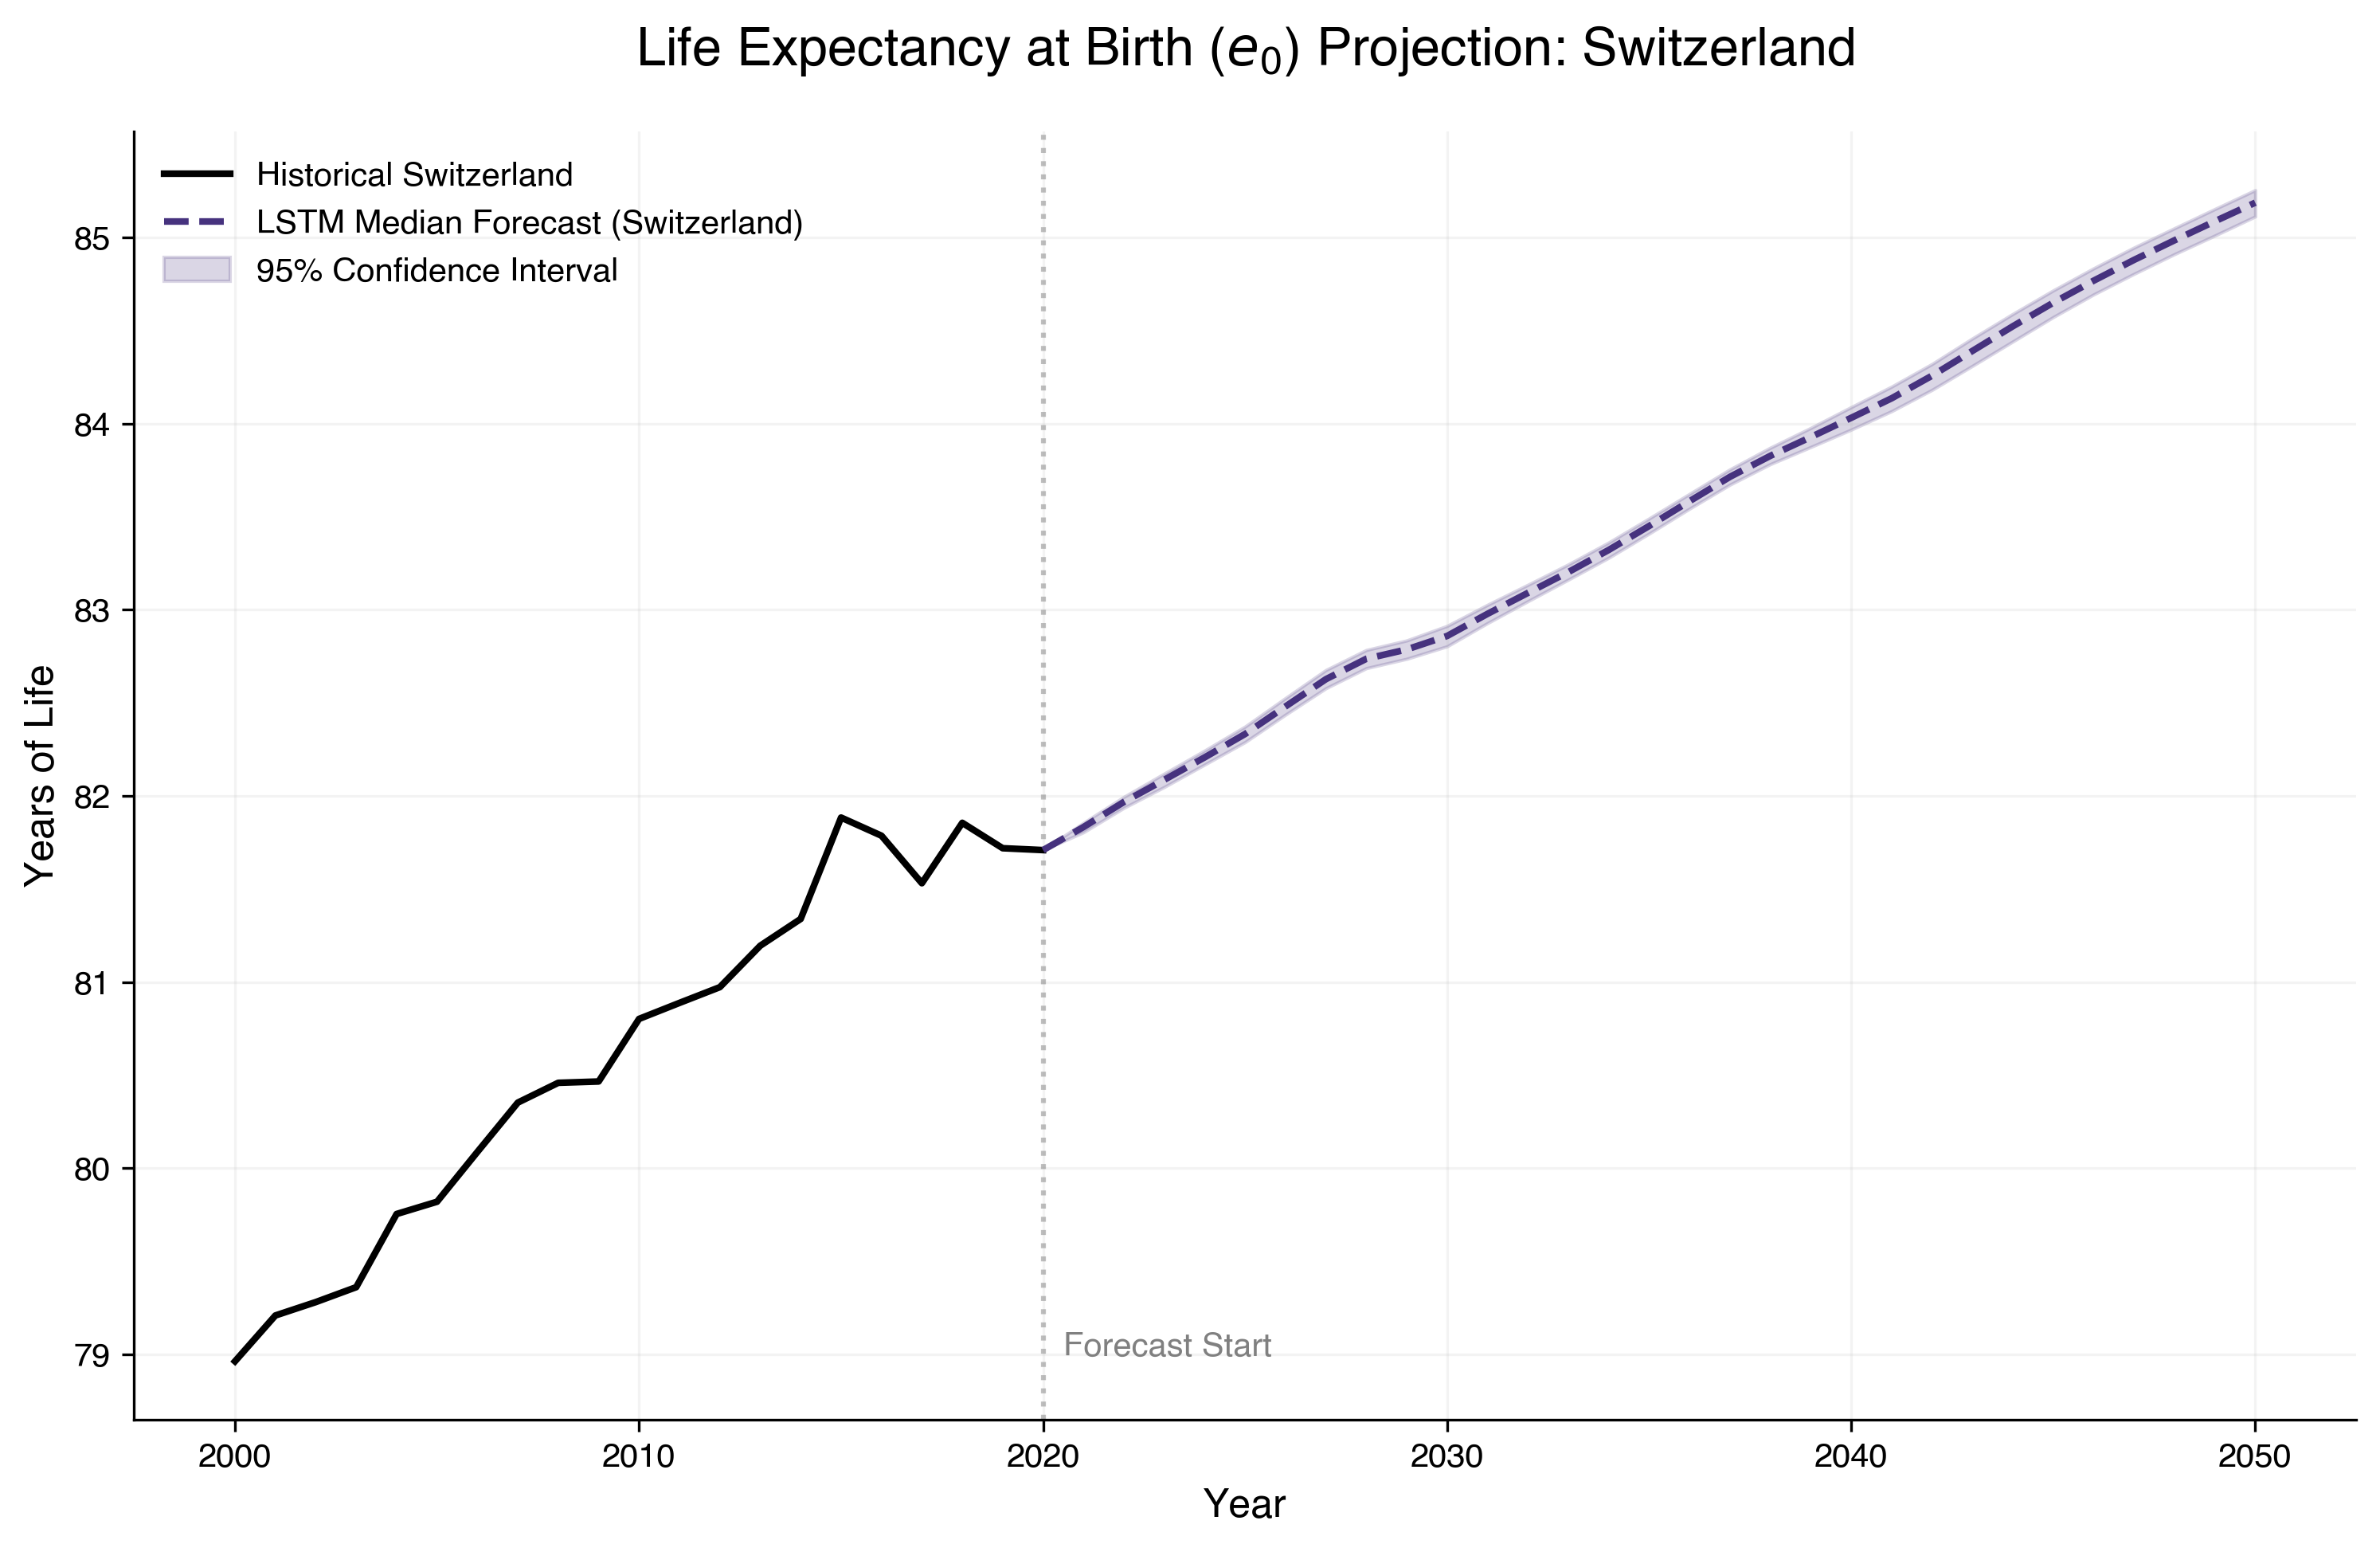

--- Figure 10 updated with style-consistent colors ---


In [7]:
# 1. Access the correct color for Switzerland (CHE)
# Based on set_style(), CHE is the first country (index 0)
# We ensure we use the same palette used in Notebook 02/03
full_palette = sns.color_palette("viridis", len(COUNTRIES_DICT))
che_color = full_palette[0] 

# 2. Calculate Historical Life Expectancy (2000-2020)
hist_years_plot = years[years >= 2000]
hist_e0_values = []

for kt_val in kt_global[years >= 2000]:
    log_mx_hist = ax_country + Bx_common * kt_val
    hist_e0_values.append(calculate_life_expectancy(log_mx_hist))

# 3. Setup Plot
# Figure size, DPI, and fonts are already handled by plt.rcParams via set_style()
fig, ax = plt.subplots()

# 4. Plot Historical Trend
ax.plot(hist_years_plot, hist_e0_values, 
        color='black', label=f'Historical {country_name}', 
        linewidth=2, zorder=5)

# 5. Plot LSTM Stochastic Forecast
# Median Projection - Using the specific color for Switzerland
ax.plot(forecast_years, median_e0, 
        color=che_color, linestyle='--', 
        linewidth=2, label=f'LSTM Median Forecast ({country_name})', zorder=6)

# 95% Confidence Interval (Fan)
ax.fill_between(forecast_years, lower_e0_95, upper_e0_95, 
                color=che_color, alpha=0.2, 
                label='95% Confidence Interval')

# 6. Final Annotations & Aesthetics
ax.set_title(f"Life Expectancy at Birth ($e_0$) Projection: {country_name}")
ax.set_xlabel("Year")
ax.set_ylabel("Years of Life")

# Transition vertical line
ax.axvline(x=2020, color='grey', linestyle=':', alpha=0.5)
ax.text(2020.5, ax.get_ylim()[0] + (ax.get_ylim()[1]-ax.get_ylim()[0])*0.05, 
        'Forecast Start', fontsize=10, color='grey', style='italic')

ax.legend(loc='upper left', frameon=False)

# 7. Export Figure
save_path = f"{FIGURES_DIR}fig10_e0_forecast_{country_name}.png"
plt.savefig(save_path)
plt.show()

print(f"--- Figure 10 updated with style-consistent colors ---")